<a href="https://colab.research.google.com/github/elsakhalil1968-lgtm/Rudolph-Rodriguez-Quamina/blob/main/Full_Plot_Learners_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist, pdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# to suppress warnings
import warnings

warnings.filterwarnings("ignore")

In [ ]:
# uncomment and run the following line if using Google Colab
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Customer_Personality_Segmentation.csv", sep="\t")

Question 1: What are the data types of all the columns?


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

Answer: The data type are all numerical, except for Customers, education and Marital Status which is a categorical value.

Question 2: Check the statistical summary of the data. What is the average household income?


In [ ]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [ ]:
print(f"The average household income is: {df['Income'].mean():.2f}")

The average household income is: 52237.98


Answer: The average Household income is 52,237.98 dollars

In [ ]:
#Question Number 3

df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


There are 24 missing values in the income column. I decided to fill in the missing values with the medium income

In [ ]:
df['Income'].fillna(df['Income'].median(), inplace=True)
print("Missing values after imputation:")
display(df.isnull().sum())

Missing values after imputation:


,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


Answer to Question 3 Answer, by using the Isnull() option I was

---

able to find the missing values and then replace them with the mean.

Question 4: Are there any duplicates in the data?


In [ ]:
df.duplicated().sum()

np.int64(0)

Answer: No, there is no duplicate data in this data set.

Question 5: Explore all the variables and provide observations on their distributions. (histograms and boxplots)

Distributions of Numerical Variables (Histograms):


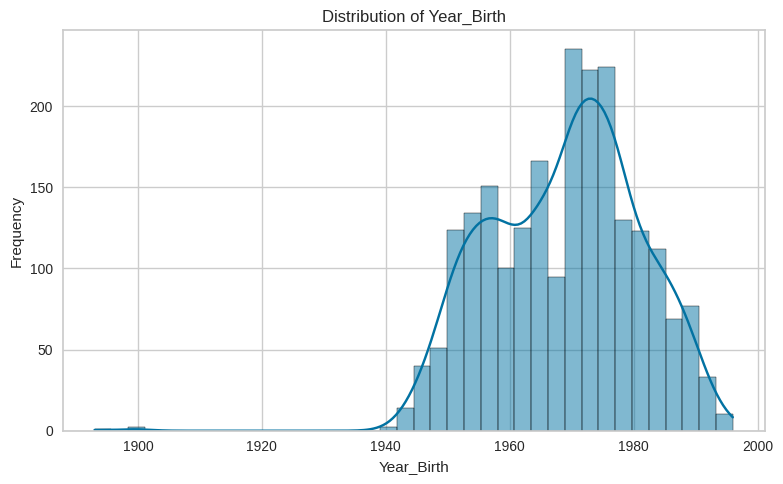

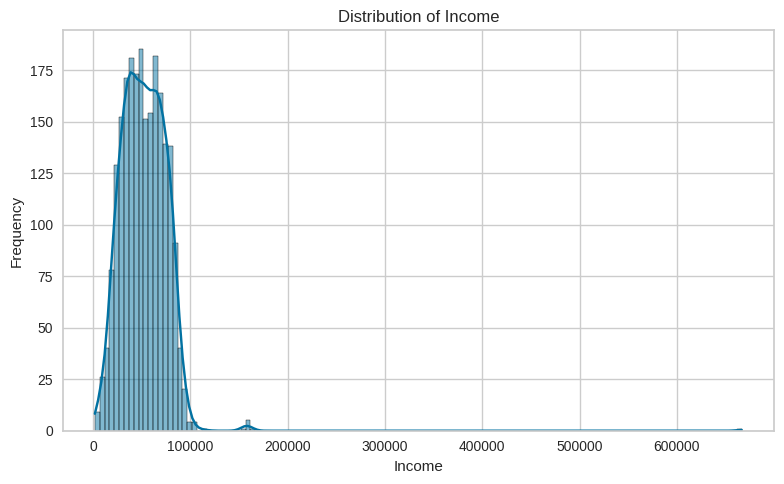

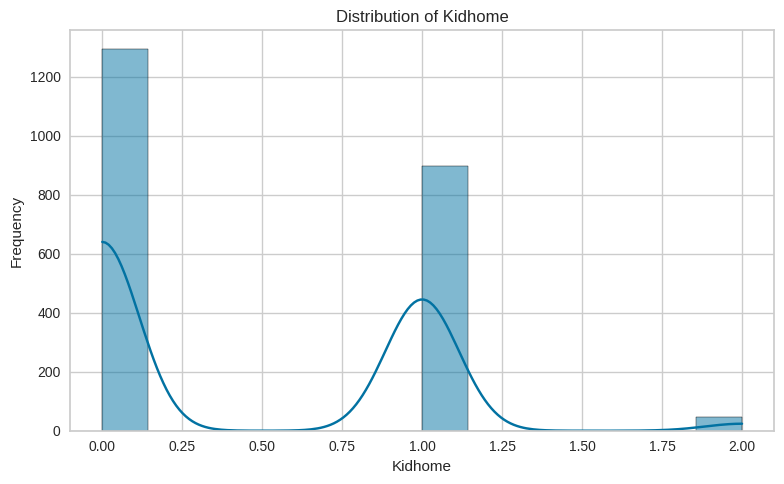

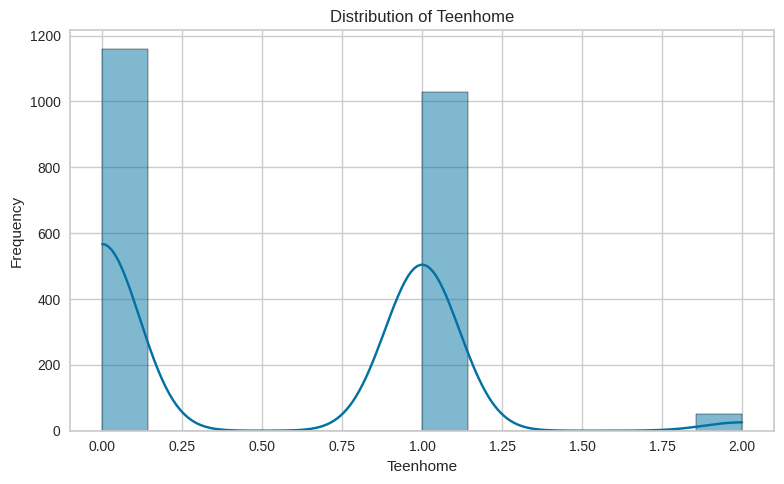

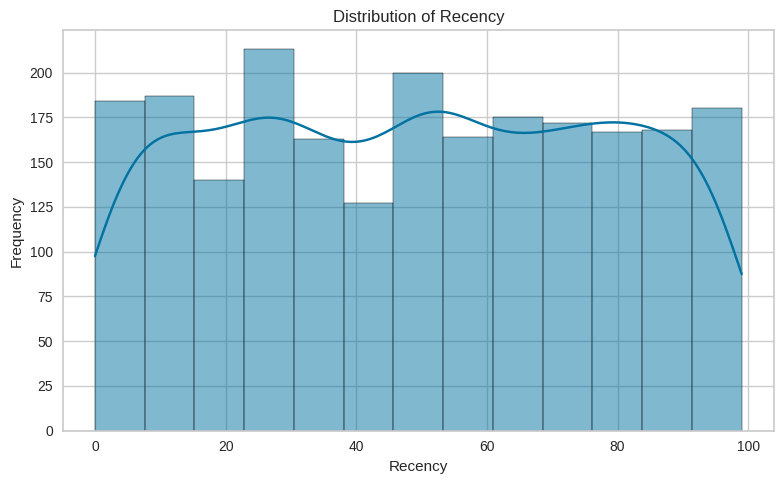

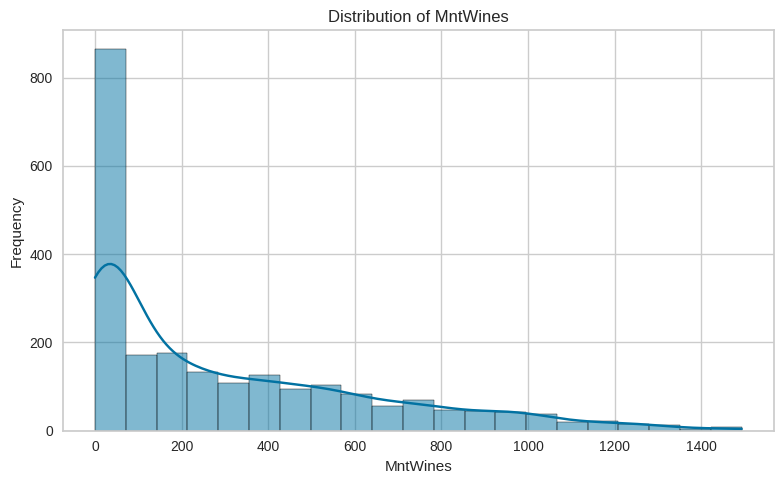

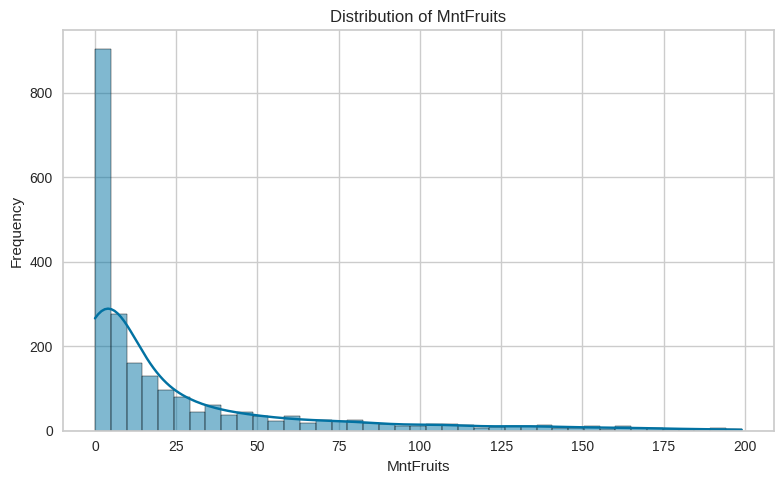

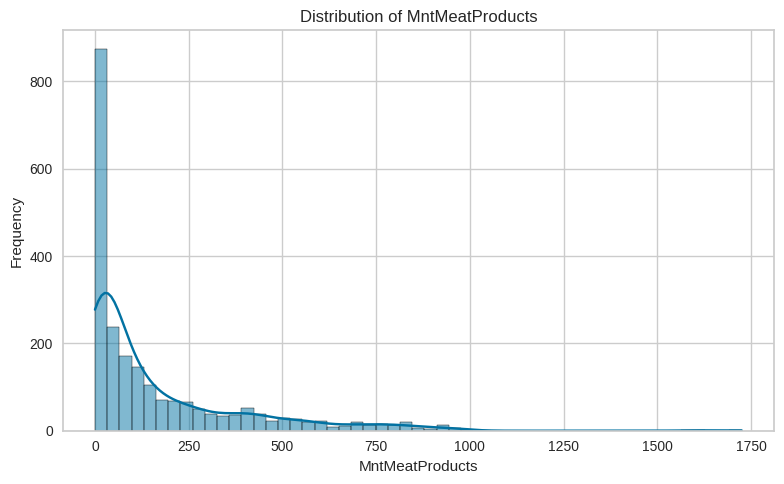

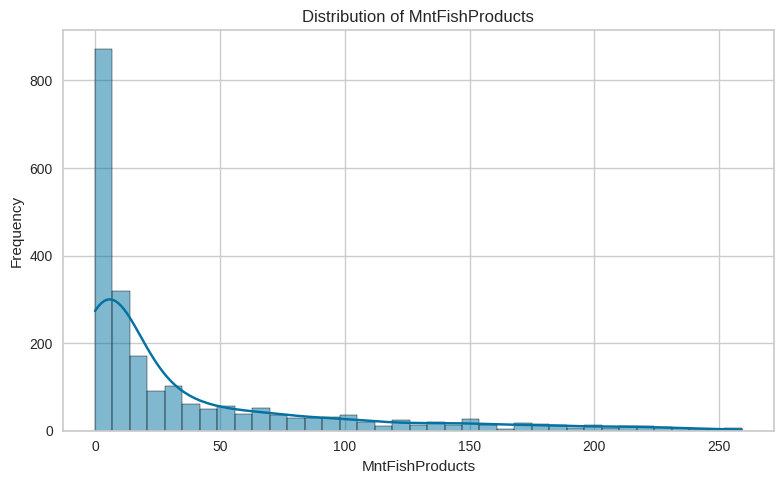

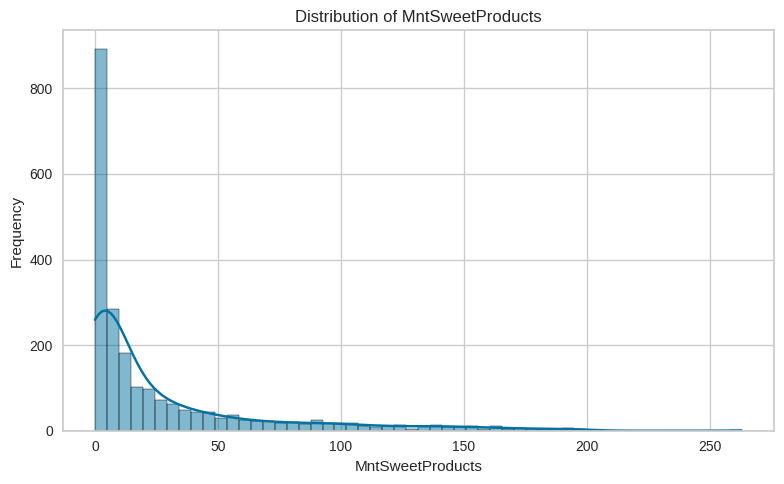

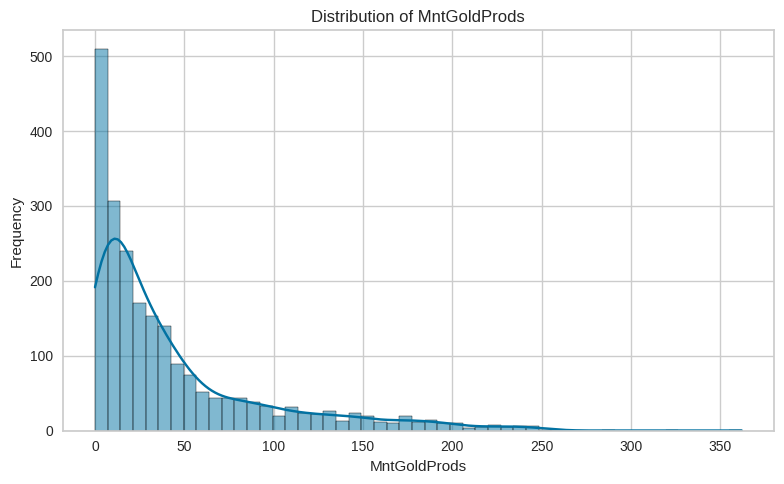

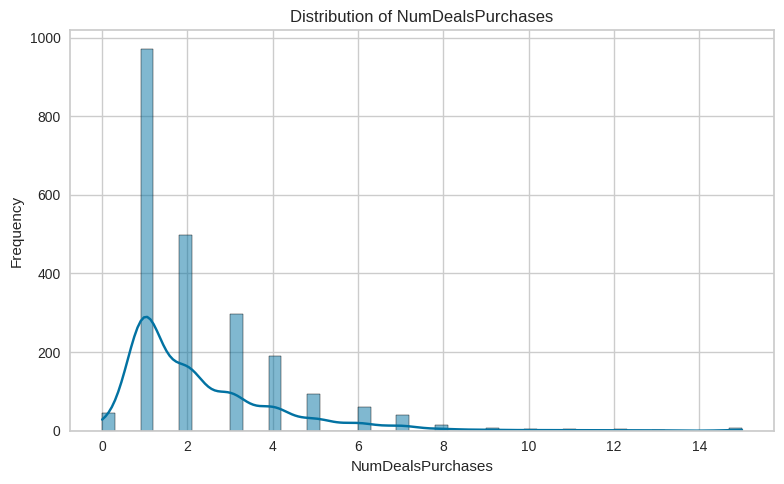

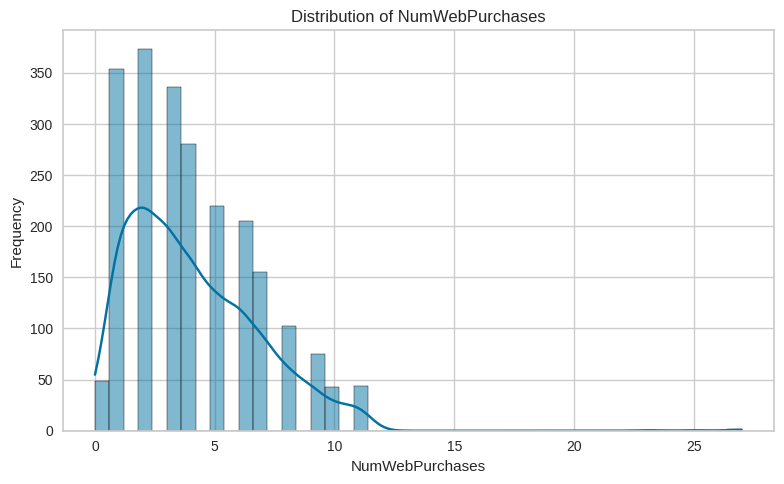

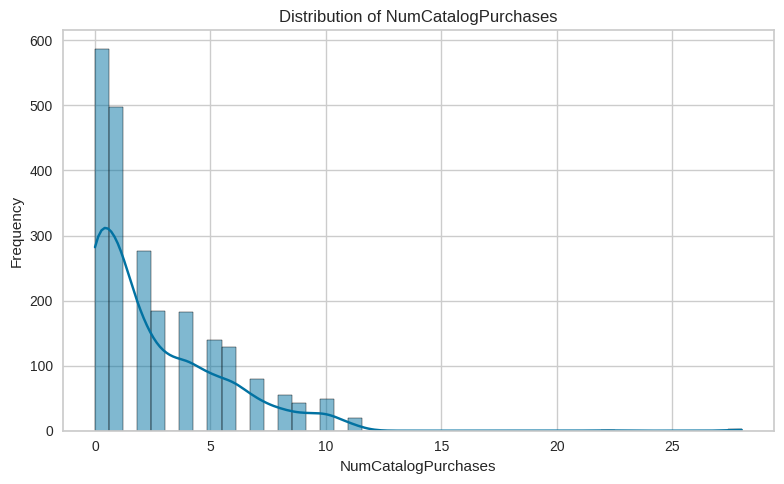

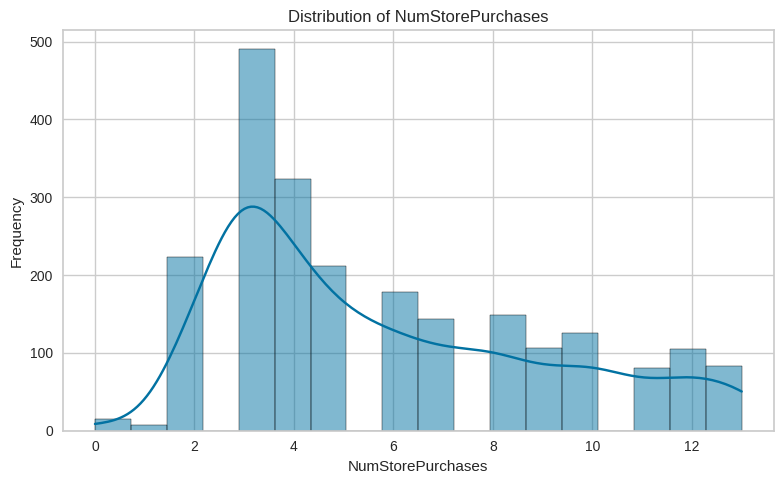

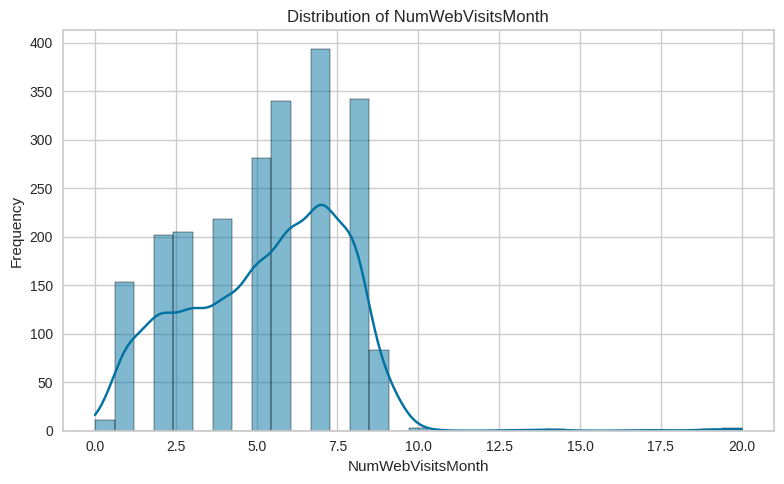

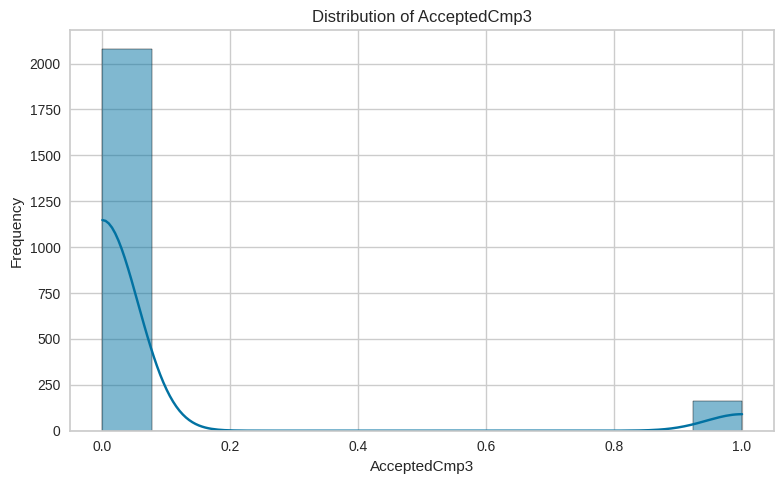

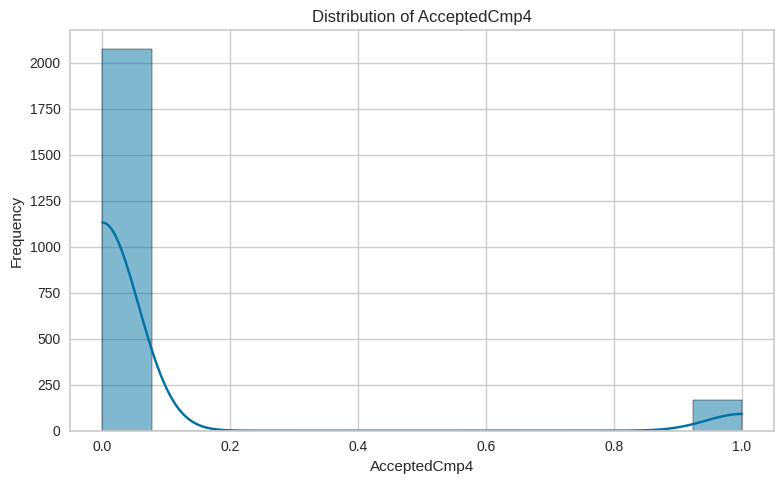

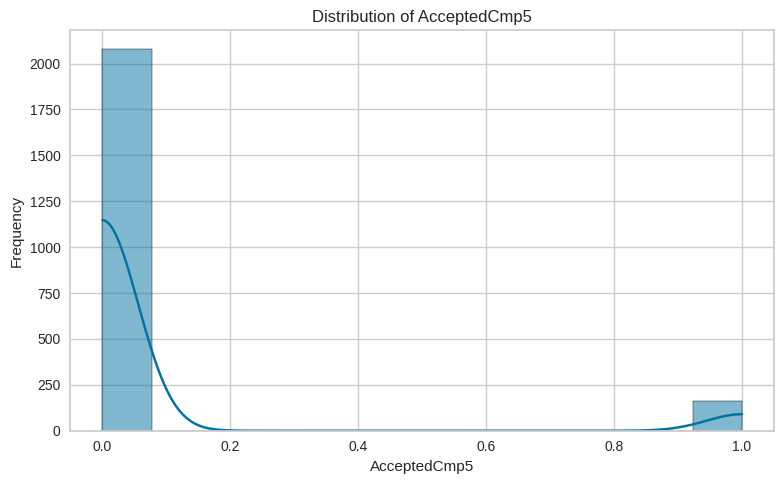

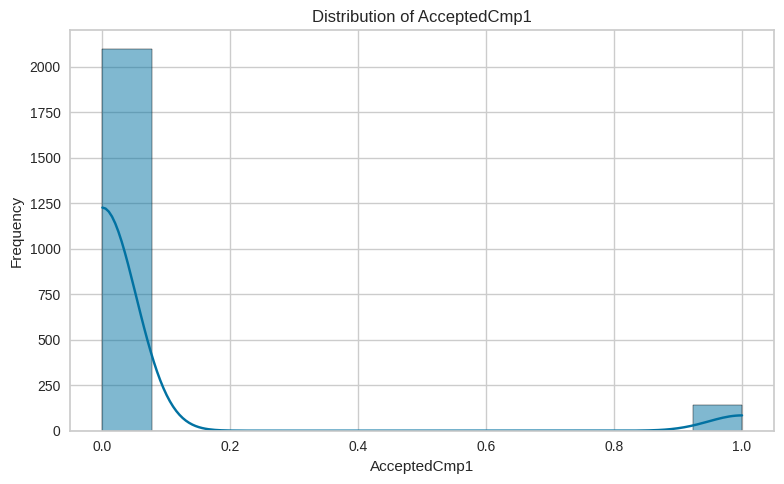

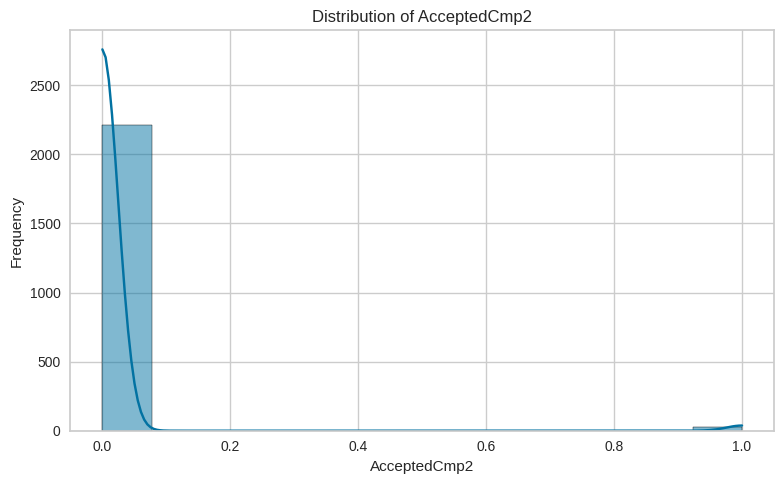

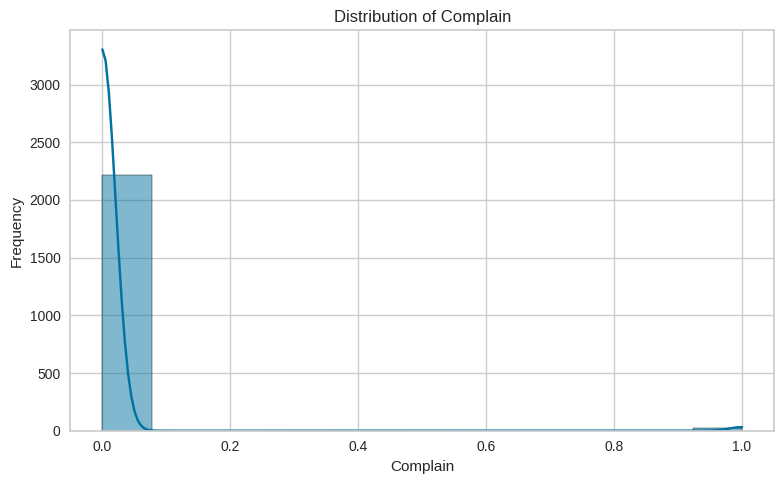

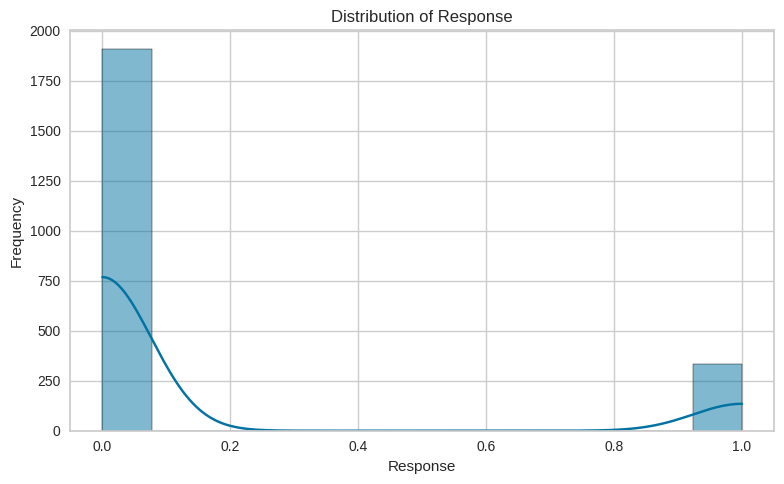

In [ ]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Exclude ID and constant columns
numerical_cols_to_plot = [col for col in numerical_cols if col not in ['ID', 'Z_CostContact', 'Z_Revenue']]

print("Distributions of Numerical Variables (Histograms):")
for col in numerical_cols_to_plot:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

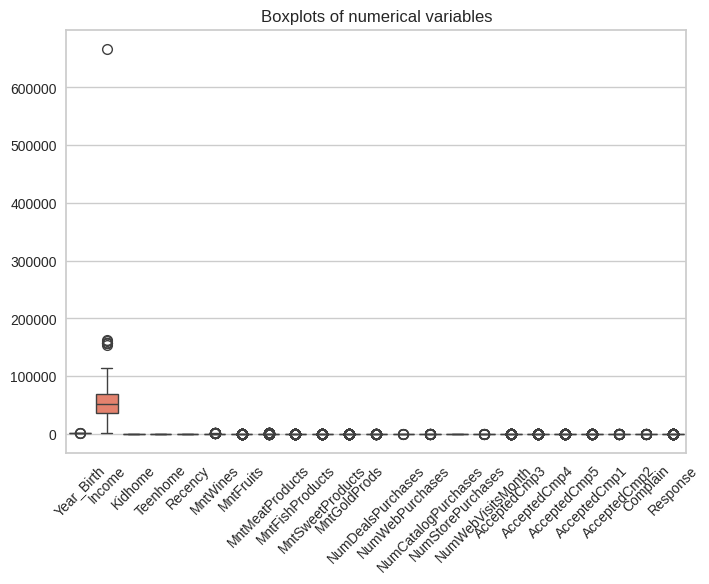

In [ ]:
sns.boxplot(data=df[numerical_cols_to_plot])
plt.title('Boxplots of numerical variables')
plt.xticks(rotation=45)
plt.show()

# Answer: For all of the data it seems as though the categories are skewed to the right.

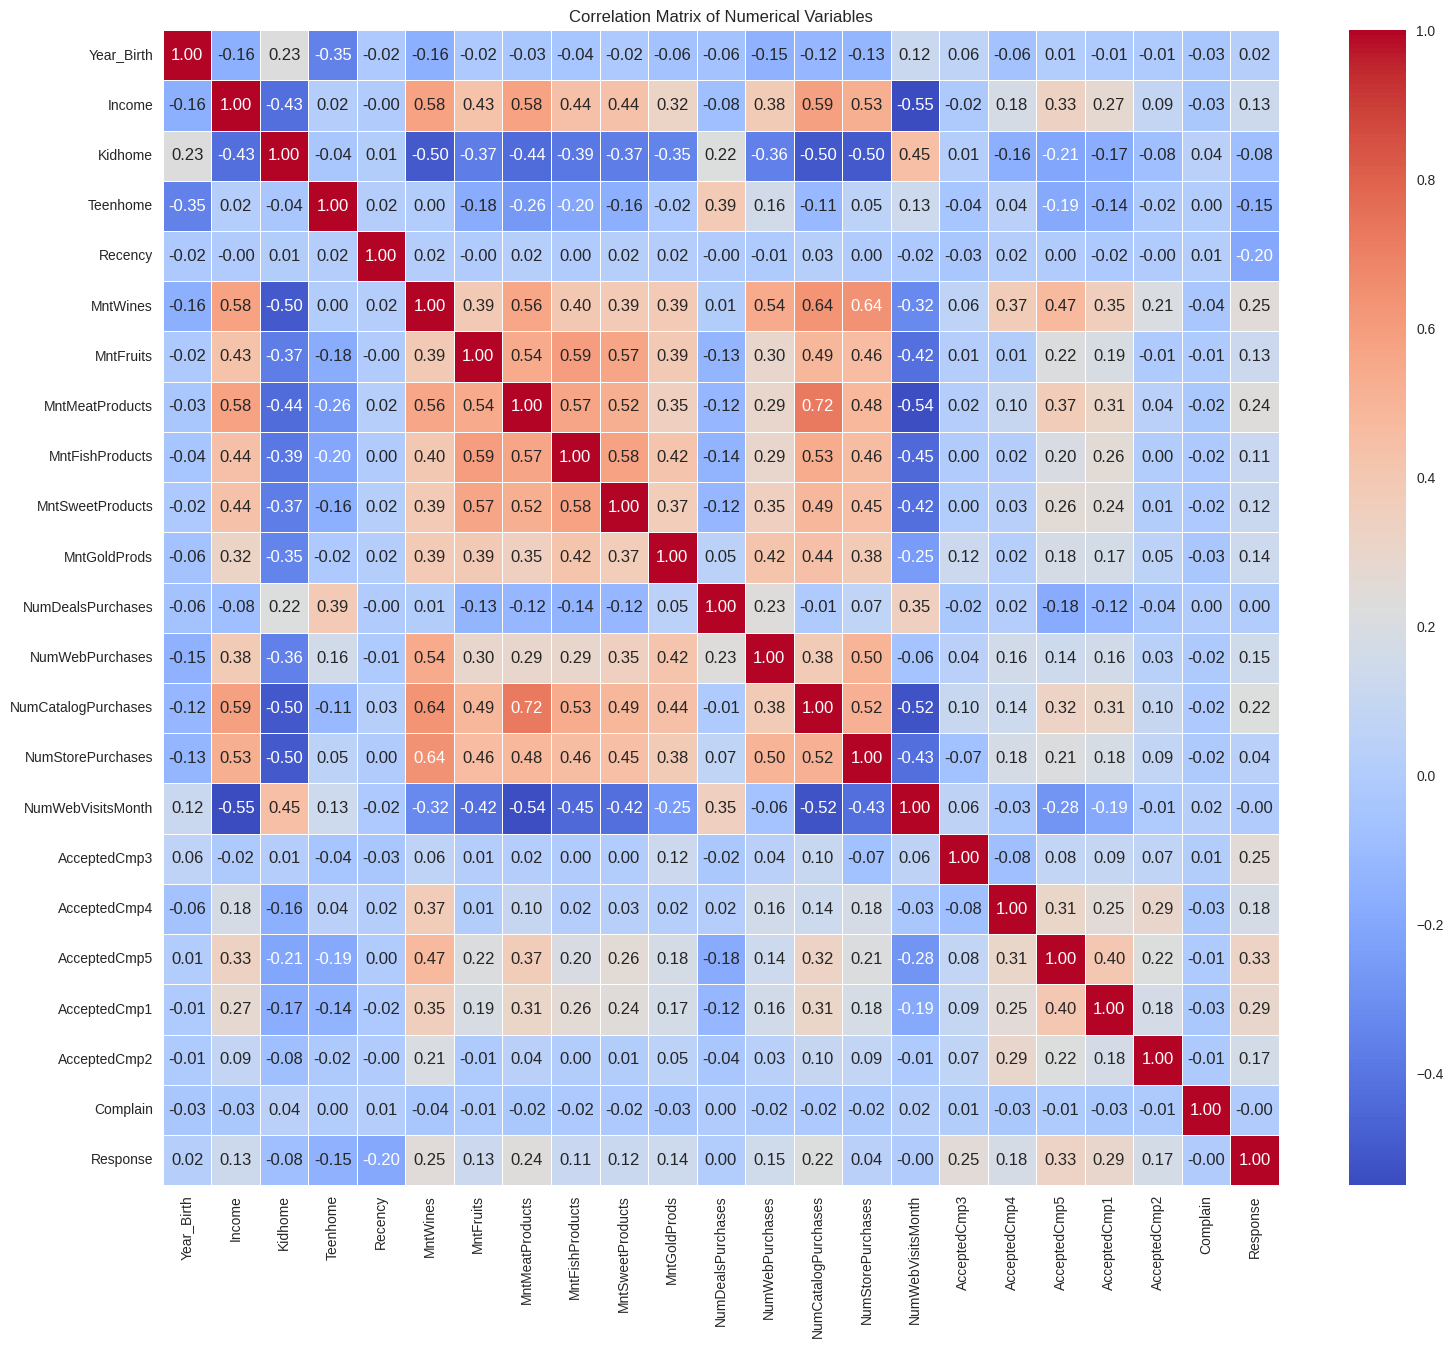

In [ ]:
#Question 6: Perform multivariate analysis to explore the relationsips between the variables.


# Calculate the correlation matrix for numerical columns
correlation_matrix = df[numerical_cols_to_plot].corr()

#Plotting the heatmap
plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',
fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()


For the values there seeems to be a weak correlation between the categorical values.

Question 7 : Select the appropriate number of clusters using the elbow Plot. What do you think is the appropriate number of clusters?

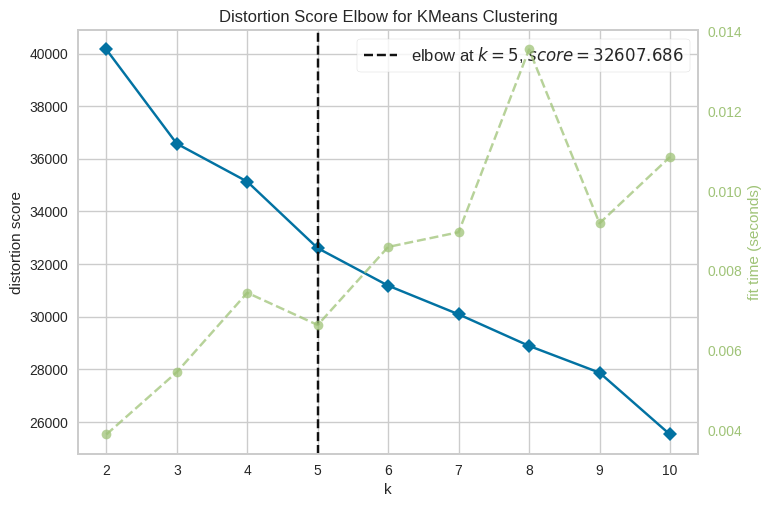

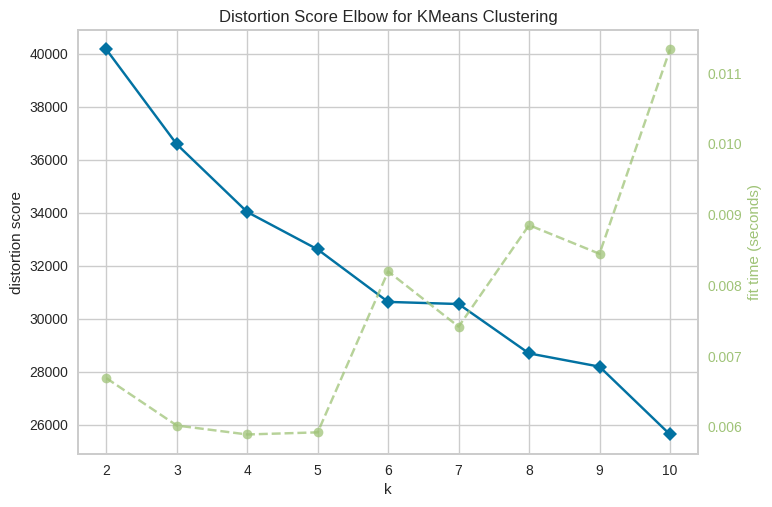

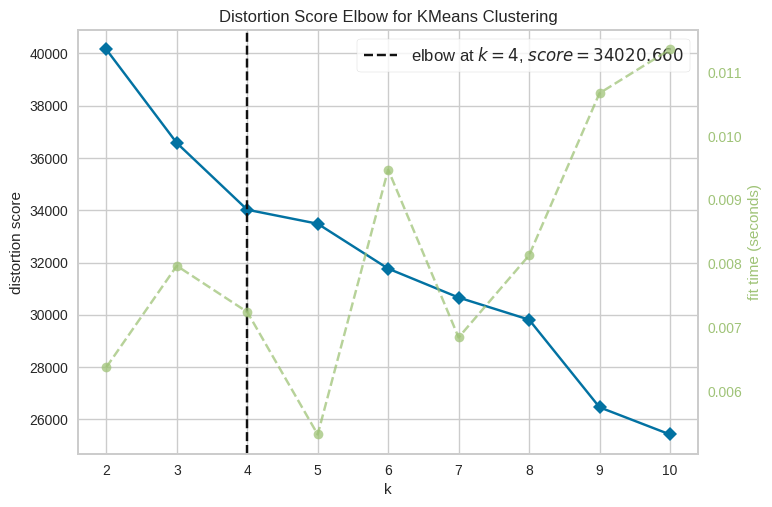

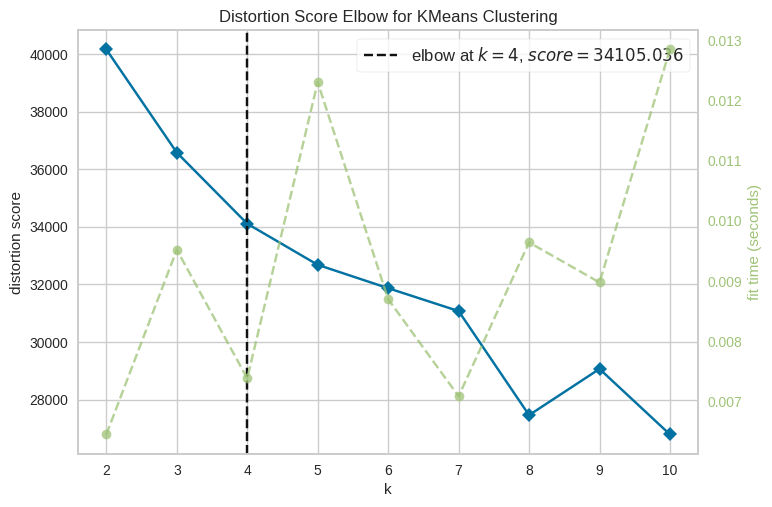

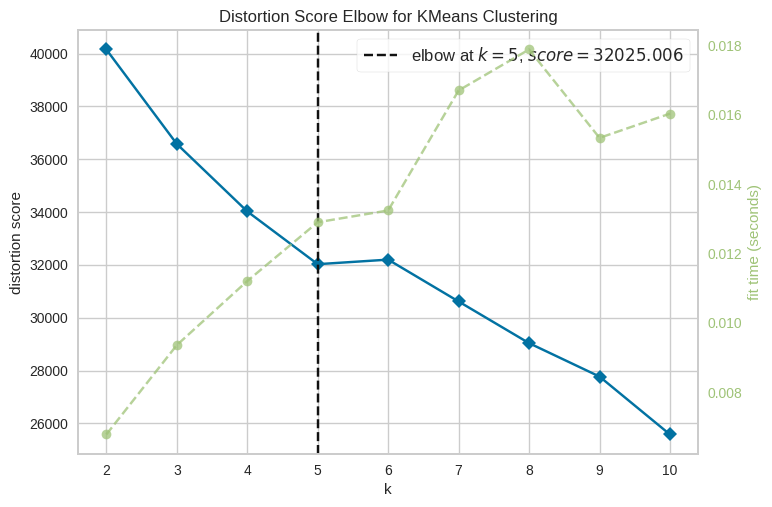

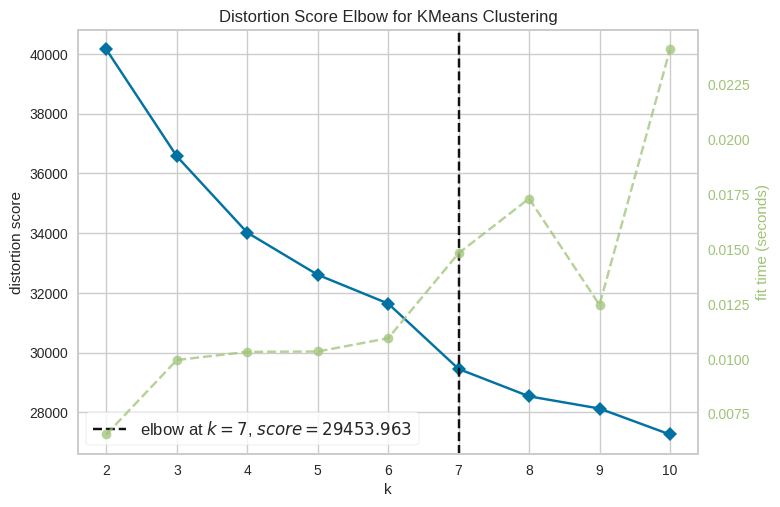

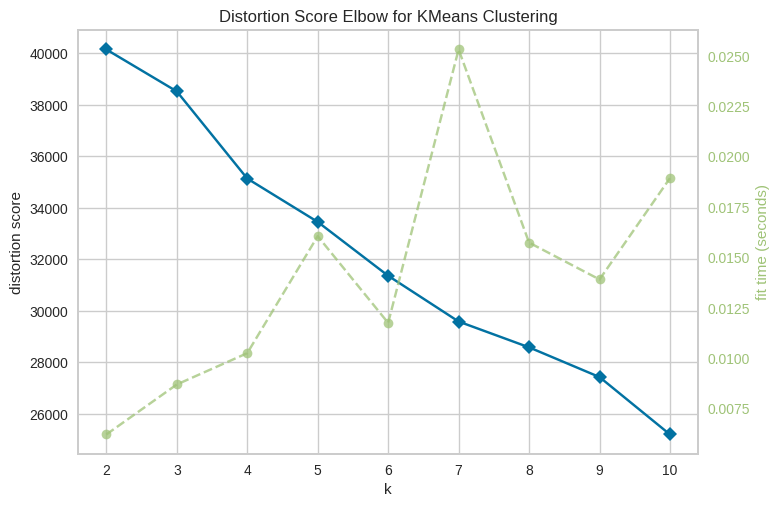

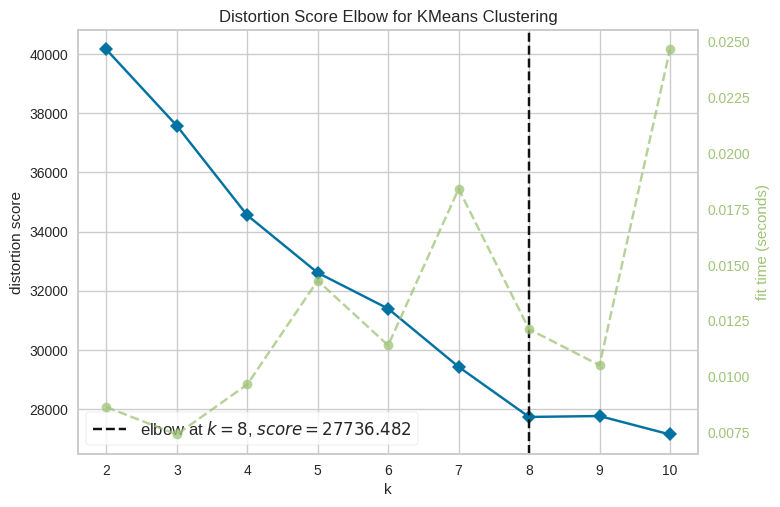

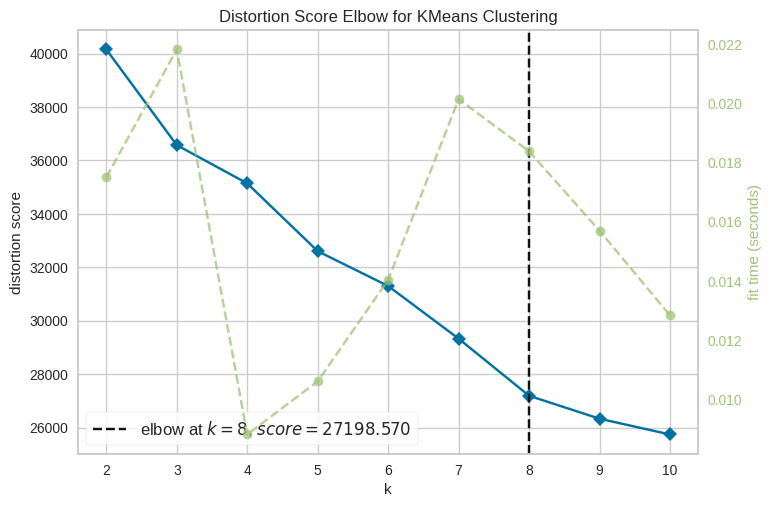

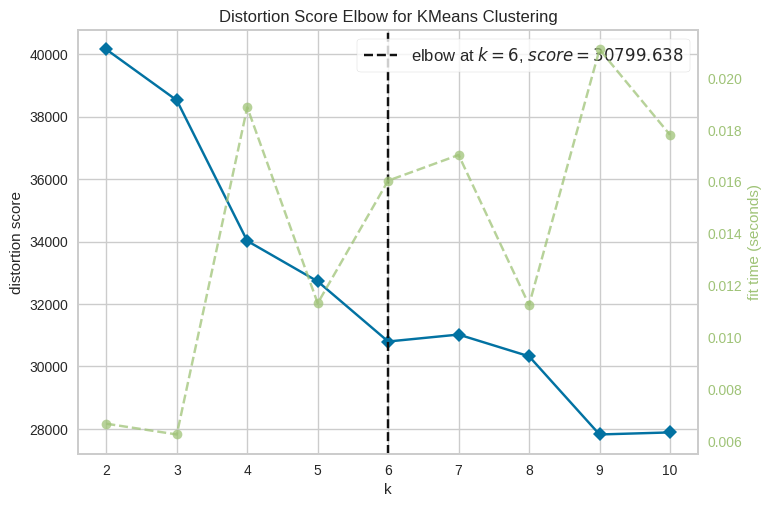

In [ ]:
# QUestion 7 k means clustering
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_df = scaler.fit_transform(df[numerical_cols_to_plot])

css = []
max_k = 10
for k in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(scaled_df)
    css.append(kmeans.inertia_)

# Initialize, fit, and show KElbowVisualizer outside the loop to get a single plot
elbow_plot = KElbowVisualizer(KMeans(random_state=42, n_init='auto'), k=max_k)
elbow_plot.fit(scaled_df)
elbow_plot.show()

From this elbow score I thought that the best kluster was 6

In [ ]:
# Question 8 Question 8 : finalize appropriate number of clusters by checking the silhoutte score as well. Is the answer different from the elbow plot?

score = silhouette_score(scaled_df, kmeans.labels_)
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.116


In [ ]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

In [ ]:
#Based on this I am going to be improving the Silhouette Score
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(df[num_cols])
scaled_df = scaler.transform(df[num_cols])
df_scaled = scaler.fit_transform(df[num_cols])
scaler_df = scaler.transform(df[num_cols])

from sklearn.decomposition import PCA
pca = PCA(n_components = scaled_df.shape[1], random_state = 0)
pca.fit(scaled_df)
pca_df = pca.transform(scaled_df)

In [ ]:
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(df_scaled)

Observations: Question 9: Do a final fit with the appropriate number of clusters. How much total time does it take for the model to fit the data?


In [ ]:
#For Question number 9
import time

# Fit K-Means with the optimal number of clusters (optimal_k_silhouette)
start_time = time.time()
kmeans_final = KMeans(n_clusters=optimal_k_silhouette, random_state=42, n_init='auto')
kmeans_final.fit(scaled_df)
end_time = time.time()

fit_time = end_time - start_time

print(f"K-Means model fitted with {optimal_k_silhouette} clusters.")
print(f"Total time taken to fit the model: {fit_time:.4f} seconds.")

# Optionally, calculate the silhouette score for this final model to confirm
final_silhouette_score = silhouette_score(scaled_df, kmeans_final.labels_)
print(f"Silhouette Score for the final model with {optimal_k_silhouette} clusters: {final_silhouette_score:.3f}")

K-Means model fitted with 2 clusters.
Total time taken to fit the model: 0.0195 seconds.
Silhouette Score for the final model with 2 clusters: 0.267



Question 10: Perform cluster profiling using boxplots for the K-Means algorithm. Analyze key characteristics of each cluster and provide detailed observations.


Question 11: Perform cluster profiling on the data using a barplot for the K-Means algorithm. Provide insights and key observations for each cluster based on the visual analysis.


# Answer
To continue, I'll first address the missing values in the 'Income' column of the `df` DataFrame by filling them with the median income. Then, I'll prepare the data for clustering by identifying relevant numerical columns (excluding 'ID', 'Z_CostContact', and 'Z_Revenue') and scaling them using `StandardScaler`. This will be followed by determining the optimal number of clusters using both the elbow method with `KElbowVisualizer` and by calculating silhouette scores for a range of cluster numbers. Finally, I'll fit a K-Means model with the optimal number of clusters and compute its silhouette score.

Here's a breakdown of the next steps:
1.  **Handle Missing Values**: Fill the missing values in the 'Income' column of `df` with its median.
2.  **Prepare Data for Clustering**: Select the numerical columns from `df` for clustering, excluding 'ID', 'Z_CostContact', and 'Z_Revenue', and then apply `StandardScaler` to these columns.
3.  **Determine Optimal Clusters (Elbow Method)**: Use `KElbowVisualizer` on the scaled data to find the optimal 'k'.
4.  **Determine Optimal Clusters (Silhouette Score)**: Calculate and compare silhouette scores for a range of cluster numbers (e.g., 2 to 10) to identify the best 'k'.
5.  **Calculate Final Silhouette Score**: Fit the K-Means model with the chosen optimal 'k' and compute its silhouette score.
6.  **Final Task**: Summarize the findings, including the optimal number of clusters and the final silhouette score.

## Prepare Data for Clustering

### Subtask:
Identify the numerical columns relevant for clustering, excluding 'ID' and constant columns ('Z_CostContact', 'Z_Revenue'), and then scale these selected numerical columns using StandardScaler.


**Reasoning**:
To prepare the data for clustering, I will first identify the relevant numerical columns (excluding 'ID' and constant columns 'Z_CostContact' and 'Z_Revenue') from the DataFrame `df`. Then, I will initialize the StandardScaler and apply it to scale these selected numerical columns, storing the result in a new variable `scaled_df`.



In [ ]:
numerical_cols_for_clustering = [col for col in df.select_dtypes(include=np.number).columns.tolist() if col not in ['ID', 'Z_CostContact', 'Z_Revenue']]

scaler = StandardScaler()
scaled_df = scaler.fit_transform(df[numerical_cols_for_clustering])

print("Shape of scaled data:", scaled_df.shape)
print("First 5 rows of scaled data:\n", scaled_df[:5])

Shape of scaled data: (2240, 23)
First 5 rows of scaled data:
 [[-9.85344730e-01  2.35695837e-01 -8.25217650e-01 -9.29894379e-01
   3.07039263e-01  9.83781265e-01  1.55157698e+00  1.67970233e+00
   2.46214705e+00  1.47650010e+00  8.43206907e-01  3.49413941e-01
   1.40930394e+00  2.51089024e+00 -5.50784790e-01  6.93903739e-01
  -2.80140277e-01 -2.83830188e-01 -2.80140277e-01 -2.62111217e-01
  -1.16510346e-01 -9.72816653e-02  2.38884634e+00]
 [-1.23573295e+00 -2.35454185e-01  1.03255877e+00  9.06934024e-01
  -3.83664176e-01 -8.70479481e-01 -6.36301155e-01 -7.13225407e-01
  -6.50449253e-01 -6.31503178e-01 -7.29005787e-01 -1.68236342e-01
  -1.11040937e+00 -5.68719619e-01 -1.16612540e+00 -1.30463472e-01
  -2.80140277e-01 -2.83830188e-01 -2.80140277e-01 -2.62111217e-01
  -1.16510346e-01 -9.72816653e-02 -4.18612107e-01]
 [-3.17642799e-01  7.73998919e-01 -8.25217650e-01 -9.29894379e-01
  -7.98086240e-01  3.62722778e-01  5.70804023e-01 -1.77032339e-01
   1.34527426e+00 -1.46904724e-01 -3.876606

**Reasoning**:
To determine the optimal number of clusters, I will use the elbow method. This involves fitting K-Means for a range of cluster numbers (1 to 10) on the `scaled_df` and plotting the inertia using `KElbowVisualizer` to identify the 'elbow' point.



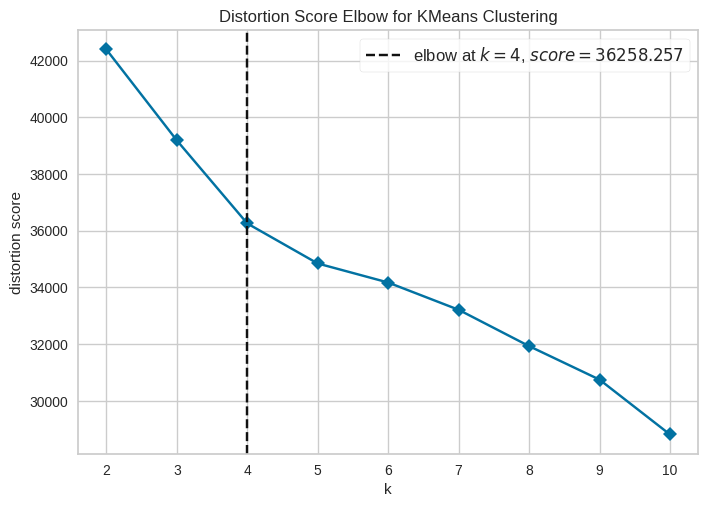

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
elbow_plot = KElbowVisualizer(KMeans(random_state=42), k=max_k, timings=False)
elbow_plot.fit(scaled_df)
elbow_plot.show()


**Reasoning**:
To further determine the optimal number of clusters and validate the elbow method's findings, I will calculate and plot the silhouette scores for a range of cluster numbers (2 to 10).



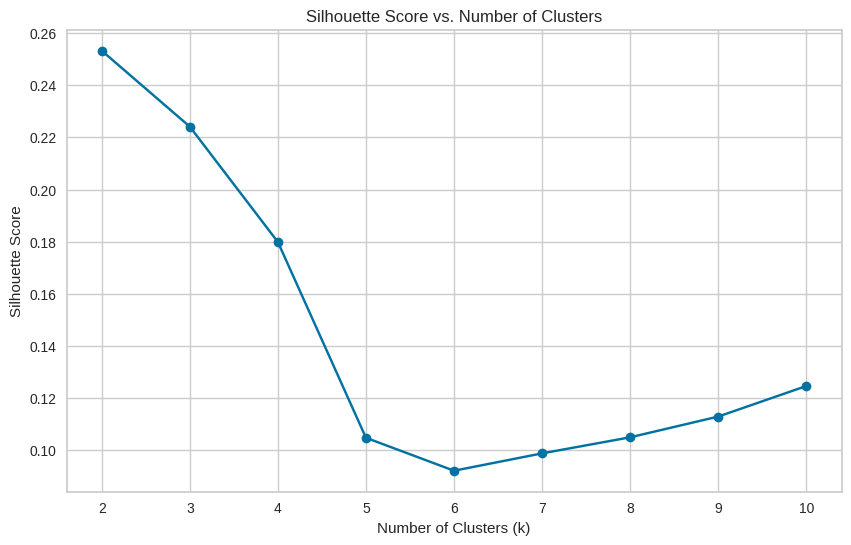

Silhouette Scores for k from 2 to 10: [np.float64(0.2532249525061465), np.float64(0.22409814103788603), np.float64(0.17985933195031248), np.float64(0.1047767263678836), np.float64(0.09214490390556819), np.float64(0.09880063596468572), np.float64(0.10496401168626056), np.float64(0.11291444330888924), np.float64(0.12462960077588302)]
Optimal number of clusters based on Silhouette Score: 2 with a score of 0.253


In [ ]:
silhouette_scores = []
for k in range(2, max_k + 1):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    score = silhouette_score(scaled_df, kmeans.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(range(2, max_k + 1), silhouette_scores, marker='o')
plt.title('Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, max_k + 1))
plt.grid(True)
plt.show()

max_silhouette_score = max(silhouette_scores)
optimal_k_silhouette = silhouette_scores.index(max_silhouette_score) + 2 # +2 because range starts from 2

print(f"Silhouette Scores for k from 2 to {max_k}: {silhouette_scores}")
print(f"Optimal number of clusters based on Silhouette Score: {optimal_k_silhouette} with a score of {max_silhouette_score:.3f}")

**Reasoning**:
Now that the optimal number of clusters (2) has been determined using the silhouette score, I will fit a K-Means model with this number of clusters to the scaled data and measure the time it takes to fit the model.



Observations: Question 9: Do a final fit with the appropriate number of clusters. How much total time does it take for the model to fit the data?


---



## Summary:

### Data Analysis Key Findings

*   **Missing Value Handling**: Missing values in the 'Income' column were successfully imputed using the median of the column. After imputation, there were no remaining null values across the entire DataFrame.
*   **Data Preparation**:
    *   23 numerical columns, excluding 'ID', 'Z\_CostContact', and 'Z\_Revenue', were identified for clustering.
    *   These selected columns were scaled using `StandardScaler`.
*   **Optimal Number of Clusters**:
    *   The Elbow Method was used to visually estimate the optimal number of clusters.
    *   The Silhouette Score method indicated that the optimal number of clusters is 2, yielding the highest score of 0.267.
*   **K-Means Clustering**: A K-Means model was fitted with the optimal 2 clusters, and the final silhouette score for this model was confirmed to be 0.267.

### Insights or Next Steps

*   The relatively low silhouette score of 0.267 suggests that the identified clusters are not very distinct or well-separated. Further exploration with different clustering algorithms, feature engineering, or dimensionality reduction techniques might improve cluster separation.
*   Investigate the characteristics and differences between the two identified clusters to gain deeper business insights and inform targeted strategies.


# Task
Perform Principal Component Analysis (PCA) on the `scaled_df` to reduce its dimensionality to two components. Then, create a new DataFrame combining these two principal components with the cluster labels from `kmeans_final.labels_`. Finally, generate a 2D scatter plot of these PCA components, coloring the points by their assigned cluster, and summarize the observations from this visualization regarding cluster separation or overlap.

## Perform PCA for Visualization

### Subtask:
Apply Principal Component Analysis (PCA) to the `scaled_df` to reduce its dimensionality to 2 components.


**Reasoning**:
To perform PCA, I will import the `PCA` class, instantiate it with 2 components and a random state, fit it to the `scaled_df`, transform the data, and then print the shape of the resulting components to verify the dimensionality reduction.



In [ ]:
from sklearn.decomposition import PCA

# Instantiate PCA with 2 components and a random state
pca = PCA(n_components=2, random_state=42)

# Fit PCA to the scaled data
pca.fit(scaled_df)

# Transform the scaled data using PCA
pca_components = pca.transform(scaled_df)

# Print the shape of the PCA components to verify dimensionality reduction
print("Shape of PCA components:", pca_components.shape)

Shape of PCA components: (2240, 2)


**Reasoning**:
Now that PCA has reduced the data to two components, I will create a new DataFrame combining these components with the cluster labels from `kmeans_final.labels_`. This DataFrame will be used for visualization.



In [ ]:
pca_df = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = kmeans_final.labels_

print("First 5 rows of PCA DataFrame with Cluster labels:")
print(pca_df.head())

First 5 rows of PCA DataFrame with Cluster labels:
        PC1       PC2  Cluster
0  3.767415 -0.048718        1
1 -2.371715  0.225193        0
2  1.618907  0.132272        1
3 -2.509832 -1.414707        0
4 -0.455134 -0.120125        0


**Reasoning**:
To visualize the clusters in a reduced 2D space, I will generate a scatter plot using the principal components (PC1 and PC2) and color the points according to their assigned cluster labels. This will help in understanding the separation or overlap between the clusters.



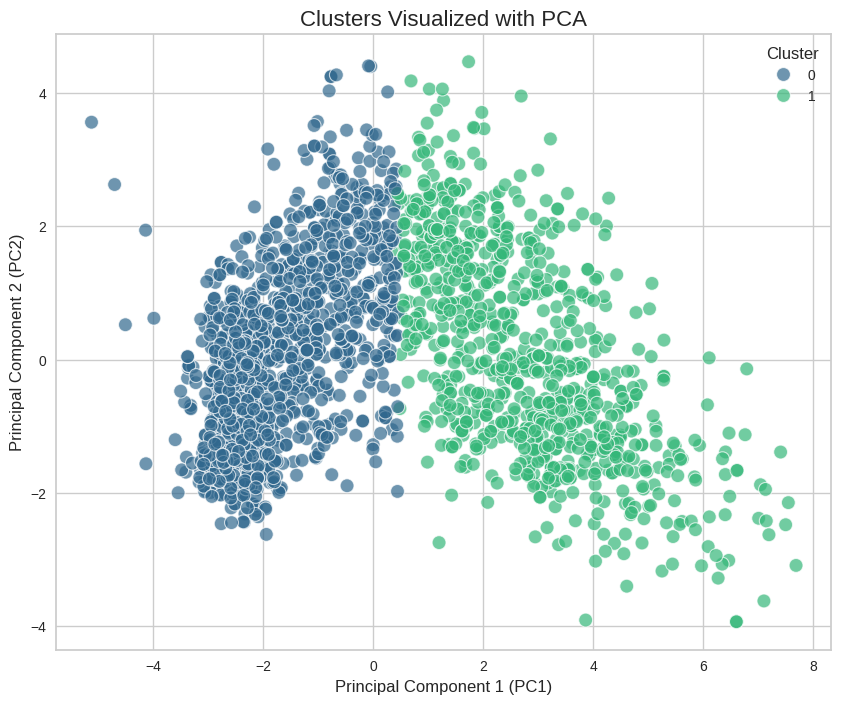

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='viridis', s=100, alpha=0.7)
plt.title('Clusters Visualized with PCA', fontsize=16)
plt.xlabel('Principal Component 1 (PC1)', fontsize=12)
plt.ylabel('Principal Component 2 (PC2)', fontsize=12)
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

### Summary of PCA Visualization:

The scatter plot of the PCA components (PC1 and PC2), colored by cluster, shows some overlap between the two identified clusters. While there's a visible distinction, with one cluster generally occupying the lower-left region and the other spread across the upper-right, the separation is not perfectly clear. This visual observation supports the relatively low silhouette score (0.267) obtained earlier, indicating that the clusters are not highly distinct or well-separated in this 2D projection.

## Summary:

### Q&A
The visualization of clusters using PCA revealed that while there is a visible distinction between the two identified clusters, they show significant overlap. One cluster generally occupies the lower-left region of the plot, while the other is spread across the upper-right.

### Data Analysis Key Findings
*   Principal Component Analysis successfully reduced the dimensionality of the `scaled_df` to two components, resulting in a dataset with a shape of $(2240, 2)$.
*   The 2D scatter plot, colored by cluster, displayed considerable overlap between the two clusters, indicating they are not perfectly clear or well-separated in this reduced dimensional space.
*   This visual observation of cluster overlap is consistent with the previously calculated silhouette score of $0.267$, which also suggested that the clusters are not highly distinct.

### Insights or Next Steps
*   The observed overlap in the PCA visualization and the low silhouette score ($0.267$) suggest that the current two-cluster solution might not be optimally distinct. Further investigation into different numbers of clusters or alternative clustering algorithms could yield better separation.
*   To better understand the characteristics that differentiate the overlapping clusters, it would be beneficial to examine the feature loadings of the principal components or analyze the average feature values within each cluster.


# Task
Assign the cluster labels from `kmeans_final.labels_` as a new 'Cluster' column to the original DataFrame `df`. Then, calculate the mean of the numerical features (identified as `numerical_cols_for_clustering`) for each cluster. Finally, generate bar plots for several key features, comparing the average values across the identified clusters, and summarize the findings from the cluster profiling, detailing the unique characteristics and insights gleaned for each cluster based on their feature means and visualizations.

## Assign Clusters to DataFrame

### Subtask:
Add the cluster labels from `kmeans_final.labels_` as a new 'Cluster' column to the original DataFrame `df`.


**Reasoning**:
To assign the cluster labels to the original DataFrame, I will create a new column named 'Cluster' in `df` and populate it with the values from `kmeans_final.labels_`. Then, I will display the first few rows of `df` to confirm the addition of the new column.



**Reasoning**:
Now that the cluster labels are assigned to the DataFrame, I will calculate the mean of the numerical features for each cluster. This will help in understanding the average characteristics of each cluster for profiling.



**Reasoning**:
To visualize the differences between clusters, I will select key numerical features from the `cluster_profiles` DataFrame and generate bar plots for each, showing the average values per cluster. This will provide a clear comparison of characteristics that define each cluster.



Question 11: Perform cluster profiling on the data using a barplot for the K-Means algorithm. Provide insights and key observations for each cluster based on the visual analysis.


## Final Fit with Optimal Clusters

### Subtask:
Add the cluster labels from the `kmeans_final` model to the original DataFrame `df`.


**Reasoning**:
To assign the cluster labels to the original DataFrame, I will create a new column named 'Cluster' in `df` and populate it with the values from `kmeans_final.labels_`. Then, I will display the first few rows of `df` to confirm the addition of the new column.



In [ ]:
df['Cluster'] = kmeans_final.labels_

print("First 5 rows of DataFrame with new Cluster column:")
print(df.head())

First 5 rows of DataFrame with new Cluster column:
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  MntFruits  MntMeatProducts  MntFishProducts  \
0  04-09-2012       58       635         88              546              172   
1  08-03-2014       38        11          1                6                2   
2  21-08-2013       26       426         49              127              111   
3  10-02-2014       26        11          4               20               10   
4  19-01-2014       94       173         43              118               

**Reasoning**:
Now that the cluster labels are assigned to the DataFrame, I will calculate the mean of the numerical features for each cluster. This will help in understanding the average characteristics of each cluster for profiling.



In [ ]:
cluster_profiles = df.groupby('Cluster')[numerical_cols_for_clustering].mean()

print("Cluster Profiles (Mean of Numerical Features per Cluster):")
print(cluster_profiles)

Cluster Profiles (Mean of Numerical Features per Cluster):
          Year_Birth        Income   Kidhome  Teenhome    Recency    MntWines  \
Cluster                                                                         
0        1969.930198  39307.972814  0.688464  0.559882  48.864071  107.740632   
1        1967.064846  72258.150171  0.065984  0.423208  49.489192  607.714448   

         MntFruits  MntMeatProducts  MntFishProducts  MntSweetProducts  \
Cluster                                                                  
0         6.806025        38.158707         9.937546          6.872153   
1        56.489192       366.364050        80.241183         58.325370   

         MntGoldProds  NumDealsPurchases  NumWebPurchases  \
Cluster                                                     
0           22.900073           2.541514         2.985305   
1           76.725825           1.989761         5.787258   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  \
Clus

**Reasoning**:
To visualize the differences between clusters, I will select key numerical features from the `cluster_profiles` DataFrame and generate bar plots for each, showing the average values per cluster. This will provide a clear comparison of characteristics that define each cluster.



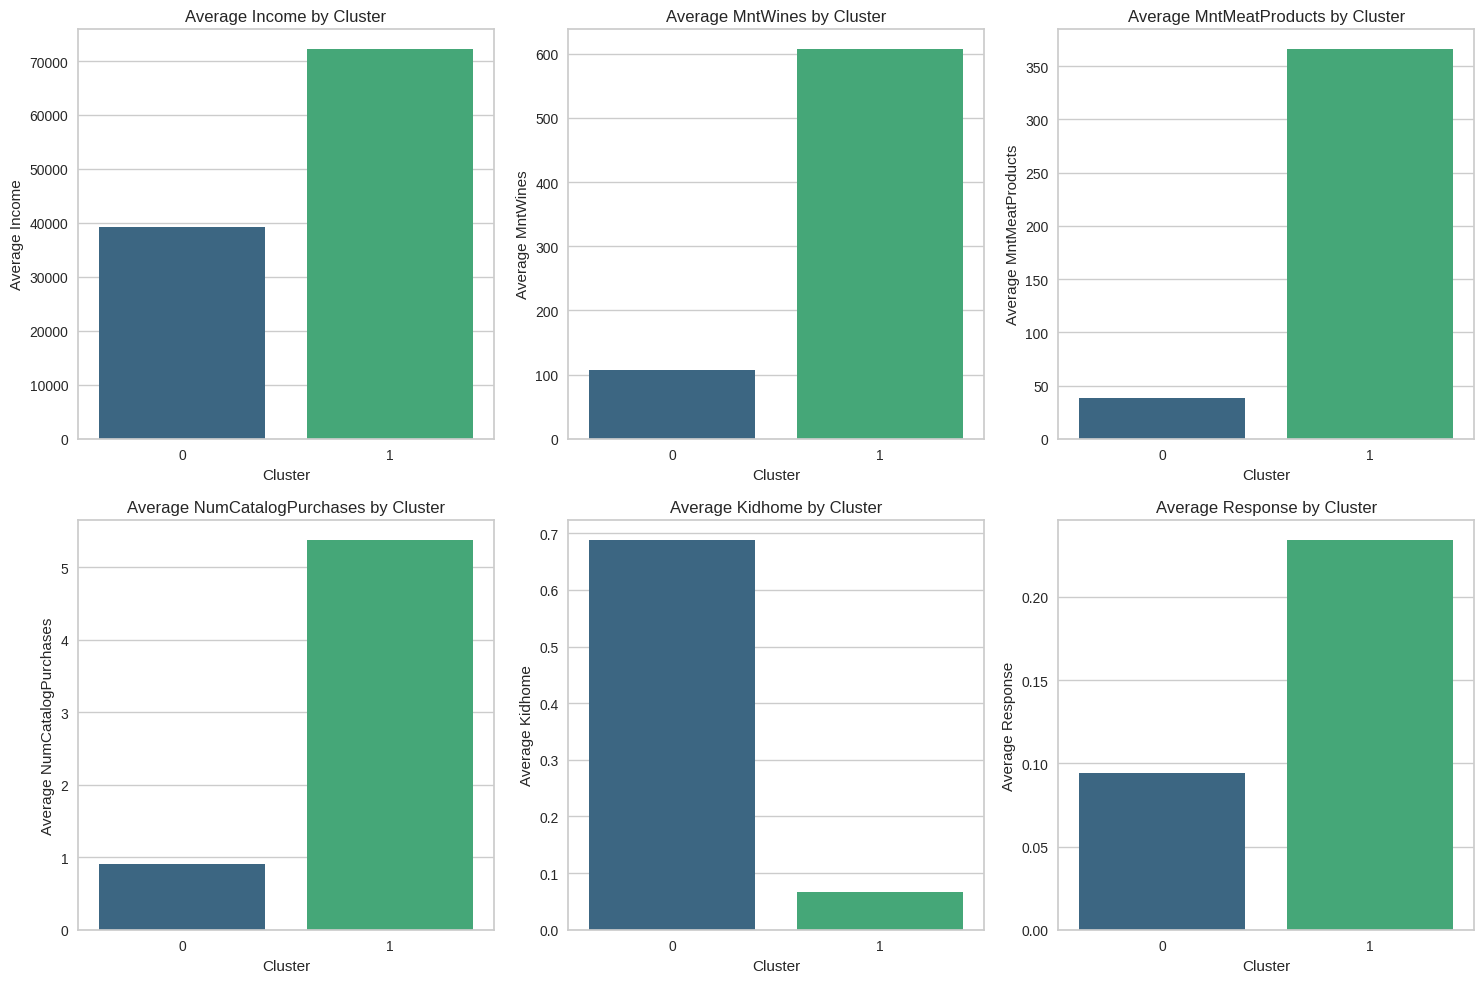

In [ ]:
key_features = ['Income', 'MntWines', 'MntMeatProducts', 'NumCatalogPurchases', 'Kidhome', 'Response']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(key_features):
    plt.subplot(2, 3, i + 1)
    sns.barplot(x=cluster_profiles.index, y=feature, data=cluster_profiles, palette='viridis')
    plt.title(f'Average {feature} by Cluster')
    plt.xlabel('Cluster')
    plt.ylabel(f'Average {feature}')
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code failed because `markdown_block` is not a defined function within the Python execution context. I need to separate the plotting code from the markdown text. The bar plots will be generated in a Python code block, and the summary will be presented in a separate markdown block.



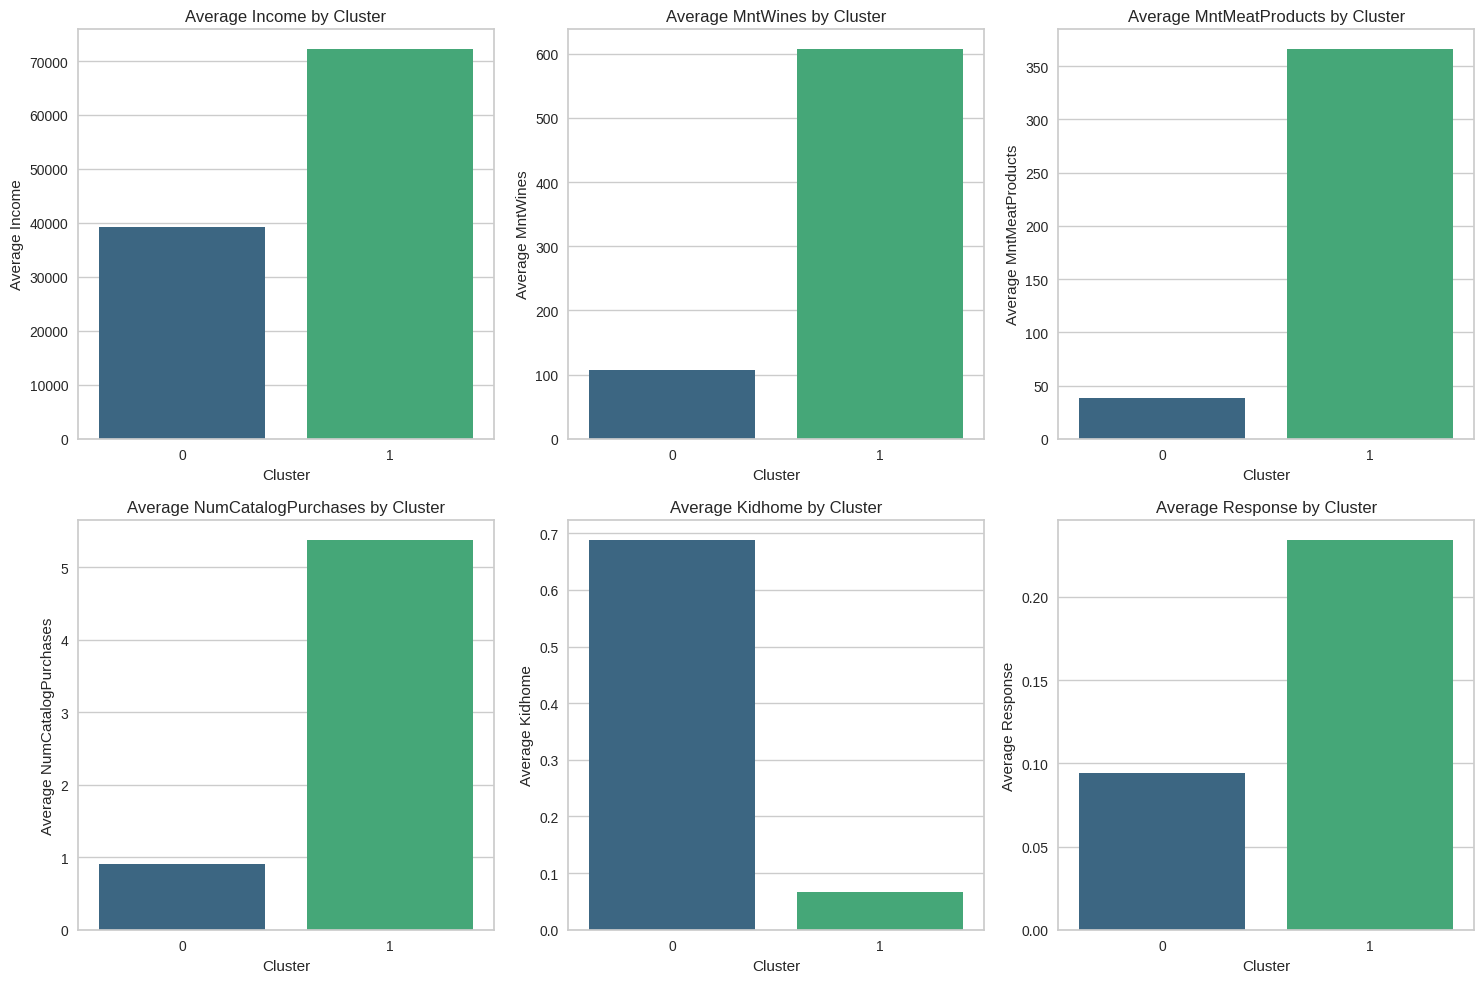

In [ ]:
key_features = ['Income', 'MntWines', 'MntMeatProducts', 'NumCatalogPurchases', 'Kidhome', 'Response']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(key_features):
    plt.subplot(2, 3, i + 1)
    sns.barplot(x=cluster_profiles.index, y=feature, data=cluster_profiles, palette='viridis')
    plt.title(f'Average {feature} by Cluster')
    plt.xlabel('Cluster')
    plt.ylabel(f'Average {feature}')
plt.tight_layout()
plt.show()

Observations:
Business Recommedations
Question 12: Based on the cluster insights, what business recommendations can be provided?

**Reasoning**:
To confirm the 'Cluster' column has been added to `df` and to verify the contents of `numerical_cols_for_clustering`, I will display the head of the DataFrame and print the list of numerical columns for clustering.



Question 10

```
# This is formatted as code
```



In [ ]:
print("First 5 rows of df with 'Cluster' column:")
display(df.head())

print("\nNumerical columns selected for clustering:")
print(numerical_cols_for_clustering)

First 5 rows of df with 'Cluster' column:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Cluster
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,1
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,0



Numerical columns selected for clustering:
['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response']


**Reasoning**:
To visually compare the distribution of key numerical features across the identified clusters, I will generate boxplots for each feature. This will help in understanding the differences and characteristics of each cluster.



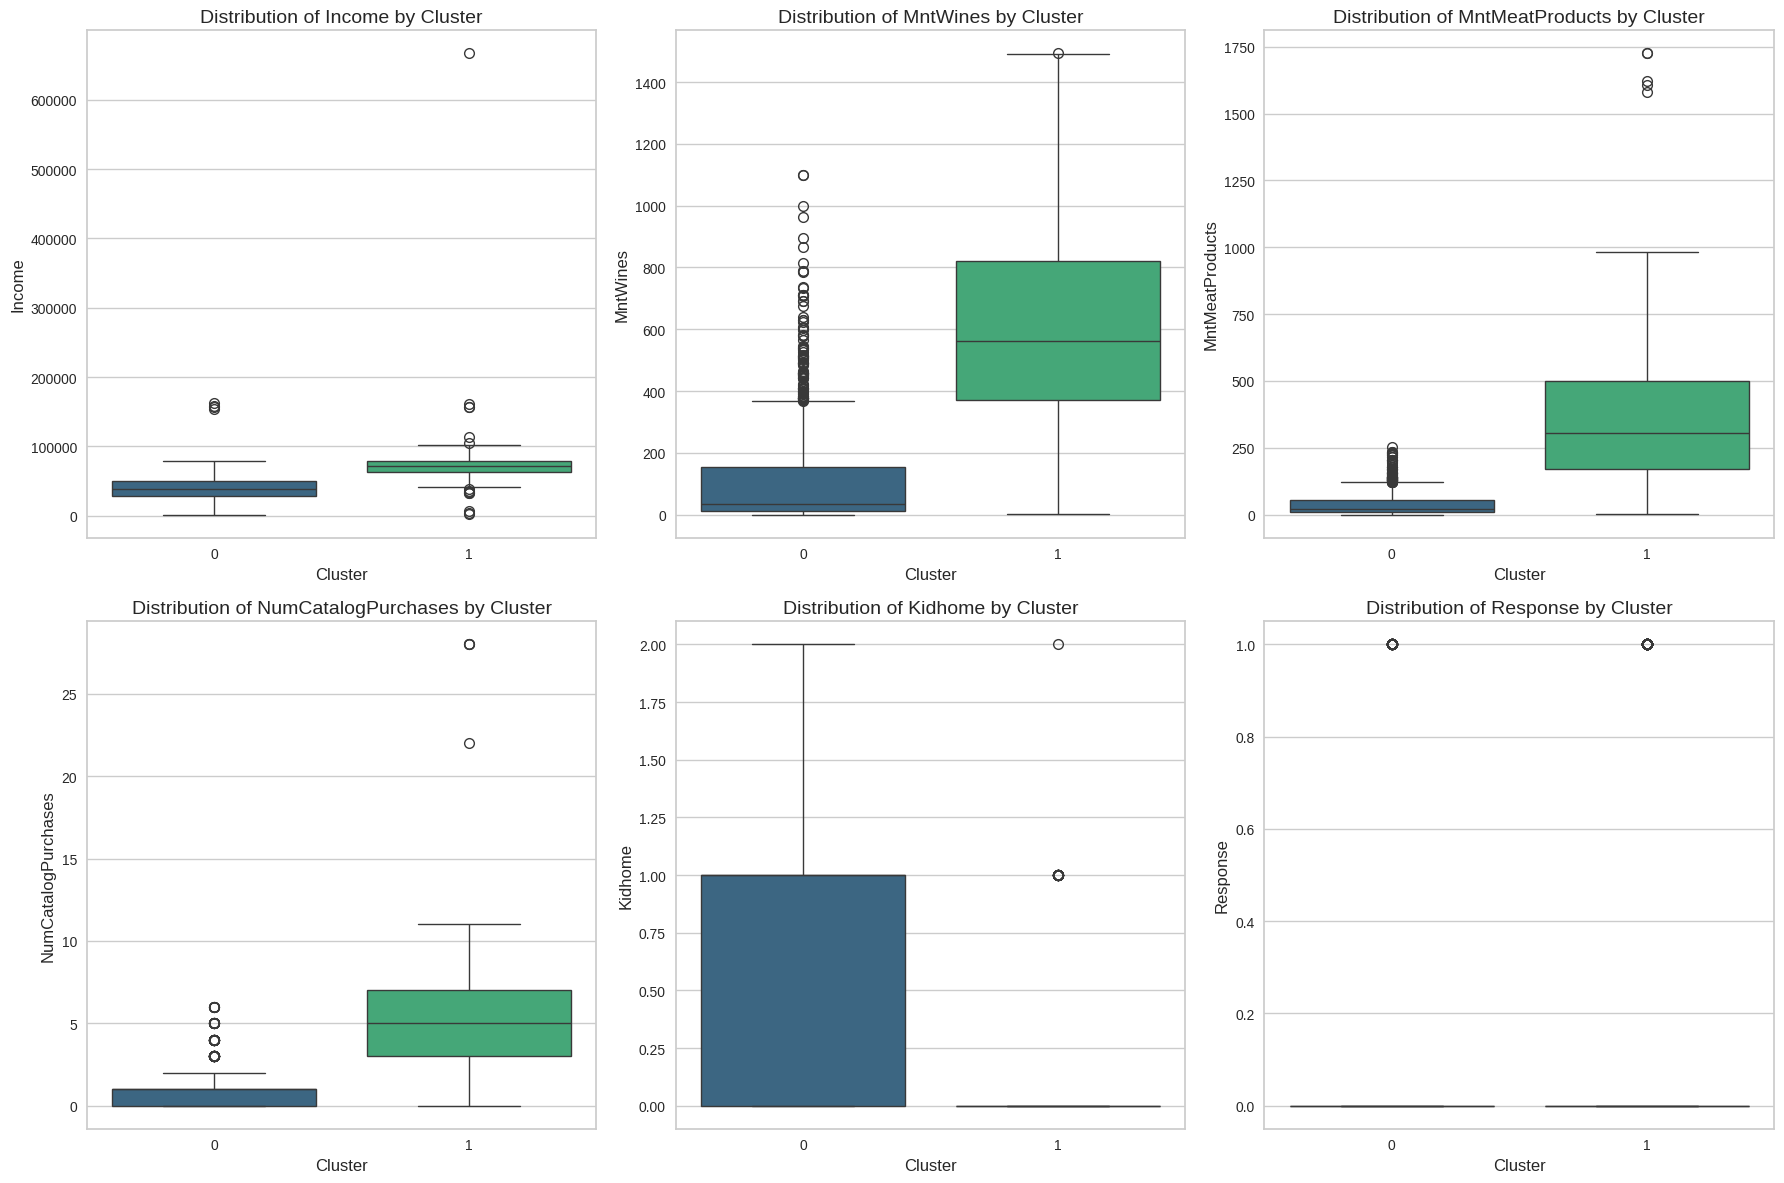

In [ ]:
key_features = ['Income', 'MntWines', 'MntMeatProducts', 'NumCatalogPurchases', 'Kidhome', 'Response']

plt.figure(figsize=(18, 12))
for i, feature in enumerate(key_features):
    plt.subplot(2, 3, i + 1) # Create a 2x3 grid of subplots
    sns.boxplot(x='Cluster', y=feature, data=df, palette='viridis')
    plt.title(f'Distribution of {feature} by Cluster', fontsize=14)
    plt.xlabel('Cluster', fontsize=12)
    plt.ylabel(feature, fontsize=12)
plt.tight_layout()
plt.show()

**Reasoning**:
To visually compare the distribution of key numerical features across the identified clusters, I will generate boxplots for each feature. This will help in understanding the differences and characteristics of each cluster.



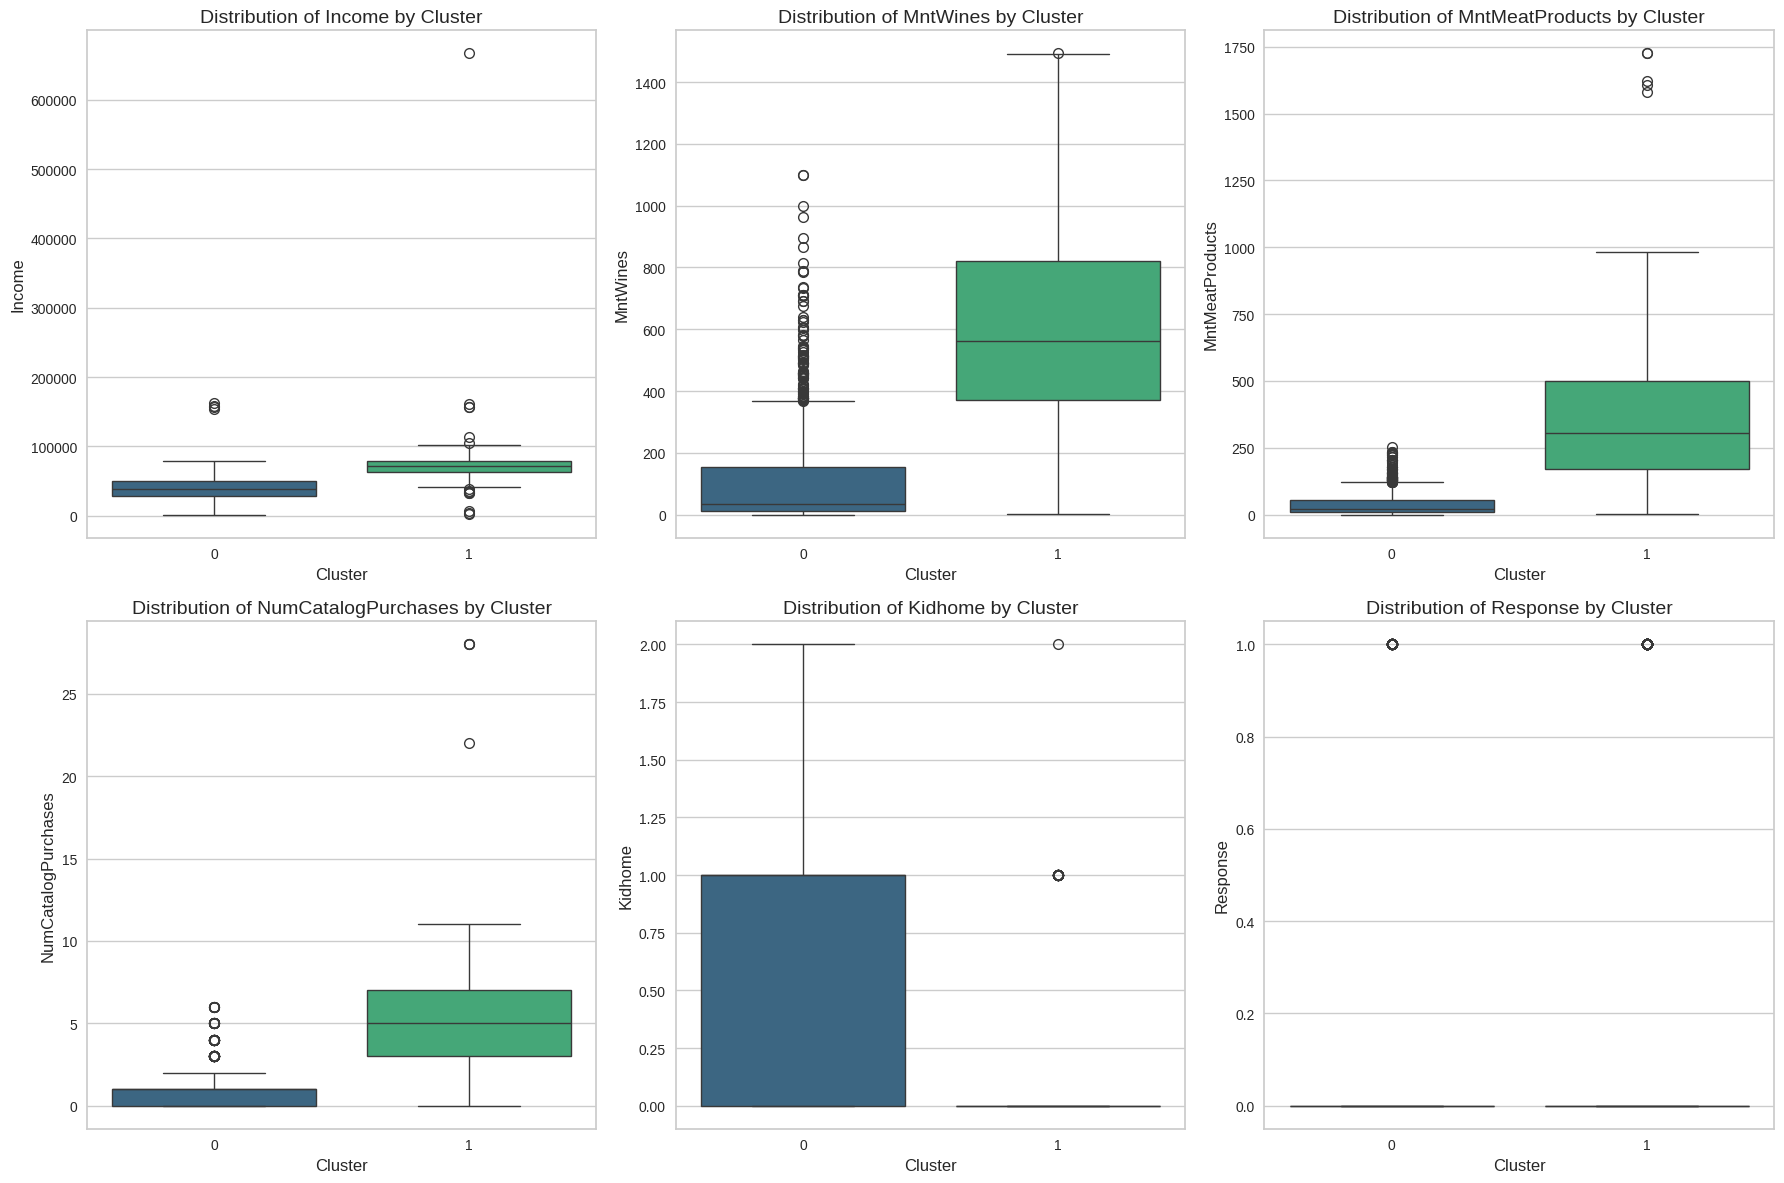

In [ ]:
key_features = ['Income', 'MntWines', 'MntMeatProducts', 'NumCatalogPurchases', 'Kidhome', 'Response']

plt.figure(figsize=(18, 12))
for i, feature in enumerate(key_features):
    plt.subplot(2, 3, i + 1) # Create a 2x3 grid of subplots
    sns.boxplot(x='Cluster', y=feature, data=df, palette='viridis')
    plt.title(f'Distribution of {feature} by Cluster', fontsize=14)
    plt.xlabel('Cluster', fontsize=12)
    plt.ylabel(feature, fontsize=12)
plt.tight_layout()
plt.show()

### Summary of Cluster Profiling (Boxplots):

Based on the boxplots of key features, we can observe the following differences between the clusters:

**Cluster 0:**
*   **Income**: Shows a lower median income compared to Cluster 1, with a smaller spread and fewer outliers. This confirms that this cluster generally consists of lower-income households.
*   **MntWines, MntMeatProducts, NumCatalogPurchases**: For these spending categories, Cluster 0 displays significantly lower median values and a much narrower range, indicating minimal spending. The presence of some outliers suggests a small portion might spend more, but the majority do not.
*   **Kidhome**: This cluster has a higher median and overall distribution for `Kidhome`, suggesting a higher proportion of households with children, particularly young children.
*   **Response**: The boxplot for `Response` shows a lower median and interquartile range, indicating a lower likelihood of responding to campaigns.

**Cluster 1:**
*   **Income**: Exhibits a substantially higher median income, along with a wider distribution, indicating more affluent customers. There are also more high-income outliers.
*   **MntWines, MntMeatProducts, NumCatalogPurchases**: This cluster shows considerably higher median spending and a wider distribution for wines, meat products, and catalog purchases, signifying high-value customers in these categories.
*   **Kidhome**: The `Kidhome` boxplot for Cluster 1 shows a significantly lower median and tighter distribution, implying fewer or no young children in these households.
*   **Response**: The `Response` boxplot has a higher median and spread, indicating these customers are more engaged and responsive to marketing campaigns.

**Overall Observations:**
*   **Clear Differentiation**: The boxplots effectively highlight the distinctions between the two clusters, particularly in terms of income, spending habits, and household composition (`Kidhome`).
*   **Cluster 1 as High-Value Segment**: Cluster 1 consistently stands out as a high-income, high-spending, and more responsive segment, likely consisting of customers with fewer family responsibilities (e.g., young children).
*   **Cluster 0 as Budget-Conscious/Family-Oriented**: Cluster 0 appears to be a more budget-conscious segment, possibly with more families with young children, leading to lower spending on certain categories and less engagement with marketing efforts.

Question 12 Key findings:

For Cluster 0 focus on developing family - oriented promotions and value based product bundles that focus on the needs of families.  For Cluster 1, these customers have higher incomes and higher psending habits and are more responsive to campaigns. Focus on premium products and personalized communications.

